## 1. Mount Google Drive
This step connects Google Colab with Google Drive so that datasets and trained models can be accessed and saved.

In [ ]:
from google.colab import drive

# Force remount if already mounted
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip -q install datasets tqdm scikit-learn

In [ ]:
from datasets import load_dataset
import os
from PIL import Image
from sklearn.model_selection import train_test_split

# Load full dataset
dataset = load_dataset("BrandonFors/Plant-Diseases-PlantVillage-Dataset")

train_data = dataset["train"]
test_data = dataset["test"]

print("Train images:", len(train_data))
print("Test images:", len(test_data))
print("Features:", train_data.features)


Train images: 43456
Test images: 10849
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Toma

In [ ]:
class_names = train_data.features["label"].names
print("Total classes:", len(class_names))
print(class_names)


Total classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', '

In [ ]:
base_dir = "/content/drive/MyDrive/plant_dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for class_name in class_names:
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

print("Folders created successfully.")


Folders created successfully.


In [ ]:
indices = list(range(len(train_data)))
labels = [train_data[i]["label"] for i in indices]

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train split:", len(train_idx))
print("Validation split:", len(val_idx))


Train split: 34764
Validation split: 8692


In [ ]:
import os

path = "/content/drive/MyDrive/plant_dataset/train"

print("Number of files:", len(os.listdir(path)))
print(os.listdir(path)[:38])  # show first 38 files

Number of files: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite',

In [ ]:
def save_images(dataset_split, indices, output_dir, prefix):
    for count, i in enumerate(indices):
        image = dataset_split[i]["image"].convert("RGB")

        label = dataset_split[i]["label"]
        class_name = class_names[label]

        class_folder = os.path.join(output_dir, class_name)
        os.makedirs(class_folder, exist_ok=True)

        file_path = os.path.join(class_folder, f"{prefix}_{i}.jpg")
        image.save(file_path)

        if count % 1000 == 0:
            print(f"Saved {count} images to {output_dir}")

# Save train images
save_images(train_data, train_idx, train_dir, "train")

# Save validation images
save_images(train_data, val_idx, val_dir, "val")

# Save test images
save_images(test_data, list(range(len(test_data))), test_dir, "test")

print("All images saved successfully.")


Saved 0 images to /content/drive/MyDrive/plant_dataset/train
Saved 1000 images to /content/drive/MyDrive/plant_dataset/train
Saved 2000 images to /content/drive/MyDrive/plant_dataset/train
Saved 3000 images to /content/drive/MyDrive/plant_dataset/train
Saved 4000 images to /content/drive/MyDrive/plant_dataset/train
Saved 5000 images to /content/drive/MyDrive/plant_dataset/train
Saved 6000 images to /content/drive/MyDrive/plant_dataset/train
Saved 7000 images to /content/drive/MyDrive/plant_dataset/train
Saved 8000 images to /content/drive/MyDrive/plant_dataset/train
Saved 9000 images to /content/drive/MyDrive/plant_dataset/train
Saved 10000 images to /content/drive/MyDrive/plant_dataset/train
Saved 11000 images to /content/drive/MyDrive/plant_dataset/train
Saved 12000 images to /content/drive/MyDrive/plant_dataset/train
Saved 13000 images to /content/drive/MyDrive/plant_dataset/train
Saved 14000 images to /content/drive/MyDrive/plant_dataset/train
Saved 15000 images to /content/drive/M

In [ ]:
import os

for split in ["train", "val", "test"]:
    split_path = os.path.join(base_dir, split)
    classes = os.listdir(split_path)

    print(f"\n{split.upper()} SET")
    print("Classes:", len(classes))

    total_images = 0
    for cls in classes:
        total_images += len(os.listdir(os.path.join(split_path, cls)))

    print("Total images:", total_images)



TRAIN SET
Classes: 38
Total images: 34764

VAL SET
Classes: 38
Total images: 8692

TEST SET
Classes: 38
Total images: 10849


In [ ]:
for split in ["train", "val", "test"]:
    split_path = os.path.join(base_dir, split)
    print(f"\nChecking {split_path}")
    print("Number of class folders:", len(os.listdir(split_path)))
    print("First 5 folders:", os.listdir(split_path)[:5])



Checking /content/drive/MyDrive/plant_dataset/train
Number of class folders: 38
First 5 folders: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Checking /content/drive/MyDrive/plant_dataset/val
Number of class folders: 38
First 5 folders: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Checking /content/drive/MyDrive/plant_dataset/test
Number of class folders: 38
First 5 folders: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


3. Import Required Libraries and Define Dataset Directory

In [ ]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

DATASET_DIR = "/content/drive/MyDrive/plant_dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Val exists:", os.path.exists(VAL_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train exists: True
Val exists: True
Test exists: True


4. Load Image Dataset (Train, Validation, Test)

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Class names:", class_names)
print("Total classes:", NUM_CLASSES)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 34764 files belonging to 38 classes.
Found 8692 files belonging to 38 classes.
Found 10849 files belonging to 38 classes.
Class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tom

5. Create Data Augmentation Layer

In [ ]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

Build and Compile Transfer Learning Model

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(128,128,3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

6. Define Training Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_path = "/content/drive/MyDrive/PlantVillage38_best_model.keras"

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("Best model saved at:", checkpoint_path)

Epoch 1/5
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.6920 - loss: 1.1553
Epoch 1: val_accuracy improved from None to 0.89646, saving model to /content/drive/MyDrive/PlantVillage38_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantVillage38_best_model.keras
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 1180s 780ms/step - accuracy: 0.8106 - loss: 0.6607 - val_accuracy: 0.8965 - val_loss: 0.3356
Epoch 2/5
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.8919 - loss: 0.3437
Epoch 2: val_accuracy improved from 0.89646 to 0.92257, saving model to /content/drive/MyDrive/PlantVillage38_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantVillage38_best_model.keras
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 1125s 773ms/step - accuracy: 0.8968 - loss: 0.3268 - val_accuracy: 0.9226 - val_loss: 0.2505
Epoch 3/5
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.9073 - loss: 0.2890
Epoch 3: val_accuracy improved from 0.92257 to 0.92913

7. Evaluate Base Model (Before Fine-Tuning)

In [ ]:
stage1_test_loss, stage1_test_acc = model.evaluate(test_ds)
print("Stage 1 Test Accuracy:", stage1_test_acc)

340/340 ━━━━━━━━━━━━━━━━━━━━ 188s 551ms/step - accuracy: 0.9286 - loss: 0.2233
Stage 1 Test Accuracy: 0.9285648465156555


8. Fine-Tune Model (Unfreeze Last 20 Layers for Improved Accuracy)

In [ ]:
base_model.trainable = True

# Freeze all layers except last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile after unfreezing
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Fine-tune the model
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/5
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.7455 - loss: 1.0527
Epoch 1: val_accuracy did not improve from 0.92913
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 1132s 879ms/step - accuracy: 0.8168 - loss: 0.6945 - val_accuracy: 0.9165 - val_loss: 0.2602
Epoch 2/5
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.8945 - loss: 0.3546
Epoch 2: val_accuracy improved from 0.92913 to 0.93063, saving model to /content/drive/MyDrive/PlantVillage38_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantVillage38_best_model.keras
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 1073s 843ms/step - accuracy: 0.8973 - loss: 0.3340 - val_accuracy: 0.9306 - val_loss: 0.2208
Epoch 3/5
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.9119 - loss: 0.2865
Epoch 3: val_accuracy improved from 0.93063 to 0.93799, saving model to /content/drive/MyDrive/PlantVillage38_best_model.keras

Epoch 3: finished saving model to /content/drive/MyDrive/PlantVillage38_best_model.keras


9. Display Fine-Tuning Training Results

In [ ]:
print("Stage 2 Best Train Accuracy:", max(history_fine.history["accuracy"]))
print("Stage 2 Best Val Accuracy:", max(history_fine.history["val_accuracy"]))

print("Stage 2 Final Train Accuracy:", history_fine.history["accuracy"][-1])
print("Stage 2 Final Val Accuracy:", history_fine.history["val_accuracy"][-1])

Stage 2 Best Train Accuracy: 0.9321712255477905
Stage 2 Best Val Accuracy: 0.9486884474754333
Stage 2 Final Train Accuracy: 0.9321712255477905
Stage 2 Final Val Accuracy: 0.9486884474754333


10. Evaluate Model After Fine-Tuning

In [ ]:
stage2_test_loss, stage2_test_acc = model.evaluate(test_ds)
print("Stage 2 Test Accuracy:", stage2_test_acc)

340/340 ━━━━━━━━━━━━━━━━━━━━ 187s 549ms/step - accuracy: 0.9486 - loss: 0.1628
Stage 2 Test Accuracy: 0.9485666751861572


11. Compare Training Results

In [ ]:
print("----- ACCURACY COMPARISON -----")
print("Stage 1 Best Val Accuracy :", max(history.history["val_accuracy"]))
print("Stage 2 Best Val Accuracy :", max(history_fine.history["val_accuracy"]))
print("Stage 1 Test Accuracy     :", stage1_test_acc)
print("Stage 2 Test Accuracy     :", stage2_test_acc)

----- ACCURACY COMPARISON -----
Stage 1 Best Val Accuracy : 0.9291302561759949
Stage 2 Best Val Accuracy : 0.9486884474754333
Stage 1 Test Accuracy     : 0.9285648465156555
Stage 2 Test Accuracy     : 0.9485666751861572


12. Save Best Model

In [ ]:
model.save("/content/drive/MyDrive/Final_PlantVillage38_model.keras")
print("Model saved at: /content/drive/MyDrive/Final_PlantVillage38_model.keras")

Model saved at: /content/drive/MyDrive/Final_PlantVillage38_model.keras


13. Import Evaluation Metrics

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Collect true labels
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Model predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

340/340 ━━━━━━━━━━━━━━━━━━━━ 197s 561ms/step


14. Visualize Training Performance (Accuracy & Loss Curves)

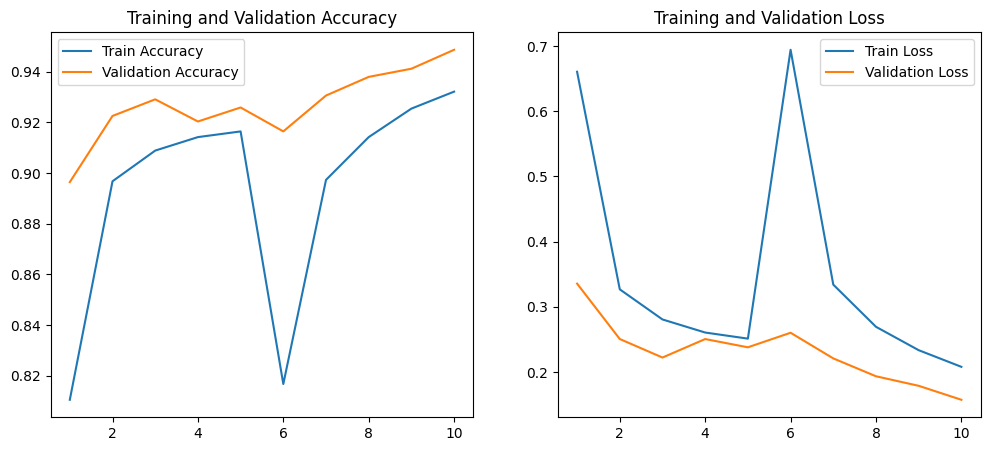

In [ ]:
import matplotlib.pyplot as plt

# Stage 1 training results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Stage 2 (fine-tuning) results
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Loss graph
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print("Predictions generated successfully.")

Predictions generated successfully.


15. Calculate Accuracy Score

In [ ]:
test_accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9485666881740252


16. Generate Classification Report

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.91      0.93       126
                                 Apple___Black_rot       0.97      0.99      0.98       124
                          Apple___Cedar_apple_rust       0.98      0.98      0.98        55
                                   Apple___healthy       0.97      0.96      0.96       329
                               Blueberry___healthy       0.99      0.98      0.98       300
          Cherry_(including_sour)___Powdery_mildew       1.00      0.97      0.98       210
                 Cherry_(including_sour)___healthy       0.89      0.99      0.94       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.86      0.81      0.83       102
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       238
               Corn_(maize)___Northern_Leaf_Blight    

17. Generate Confusion Matrix


Confusion Matrix:

[[ 115    1    1 ...    1    0    0]
 [   0  123    0 ...    0    0    0]
 [   0    0   54 ...    0    0    0]
 ...
 [   0    0    0 ... 1029    1    0]
 [   0    0    0 ...    0   70    0]
 [   0    0    0 ...    0    0  306]]


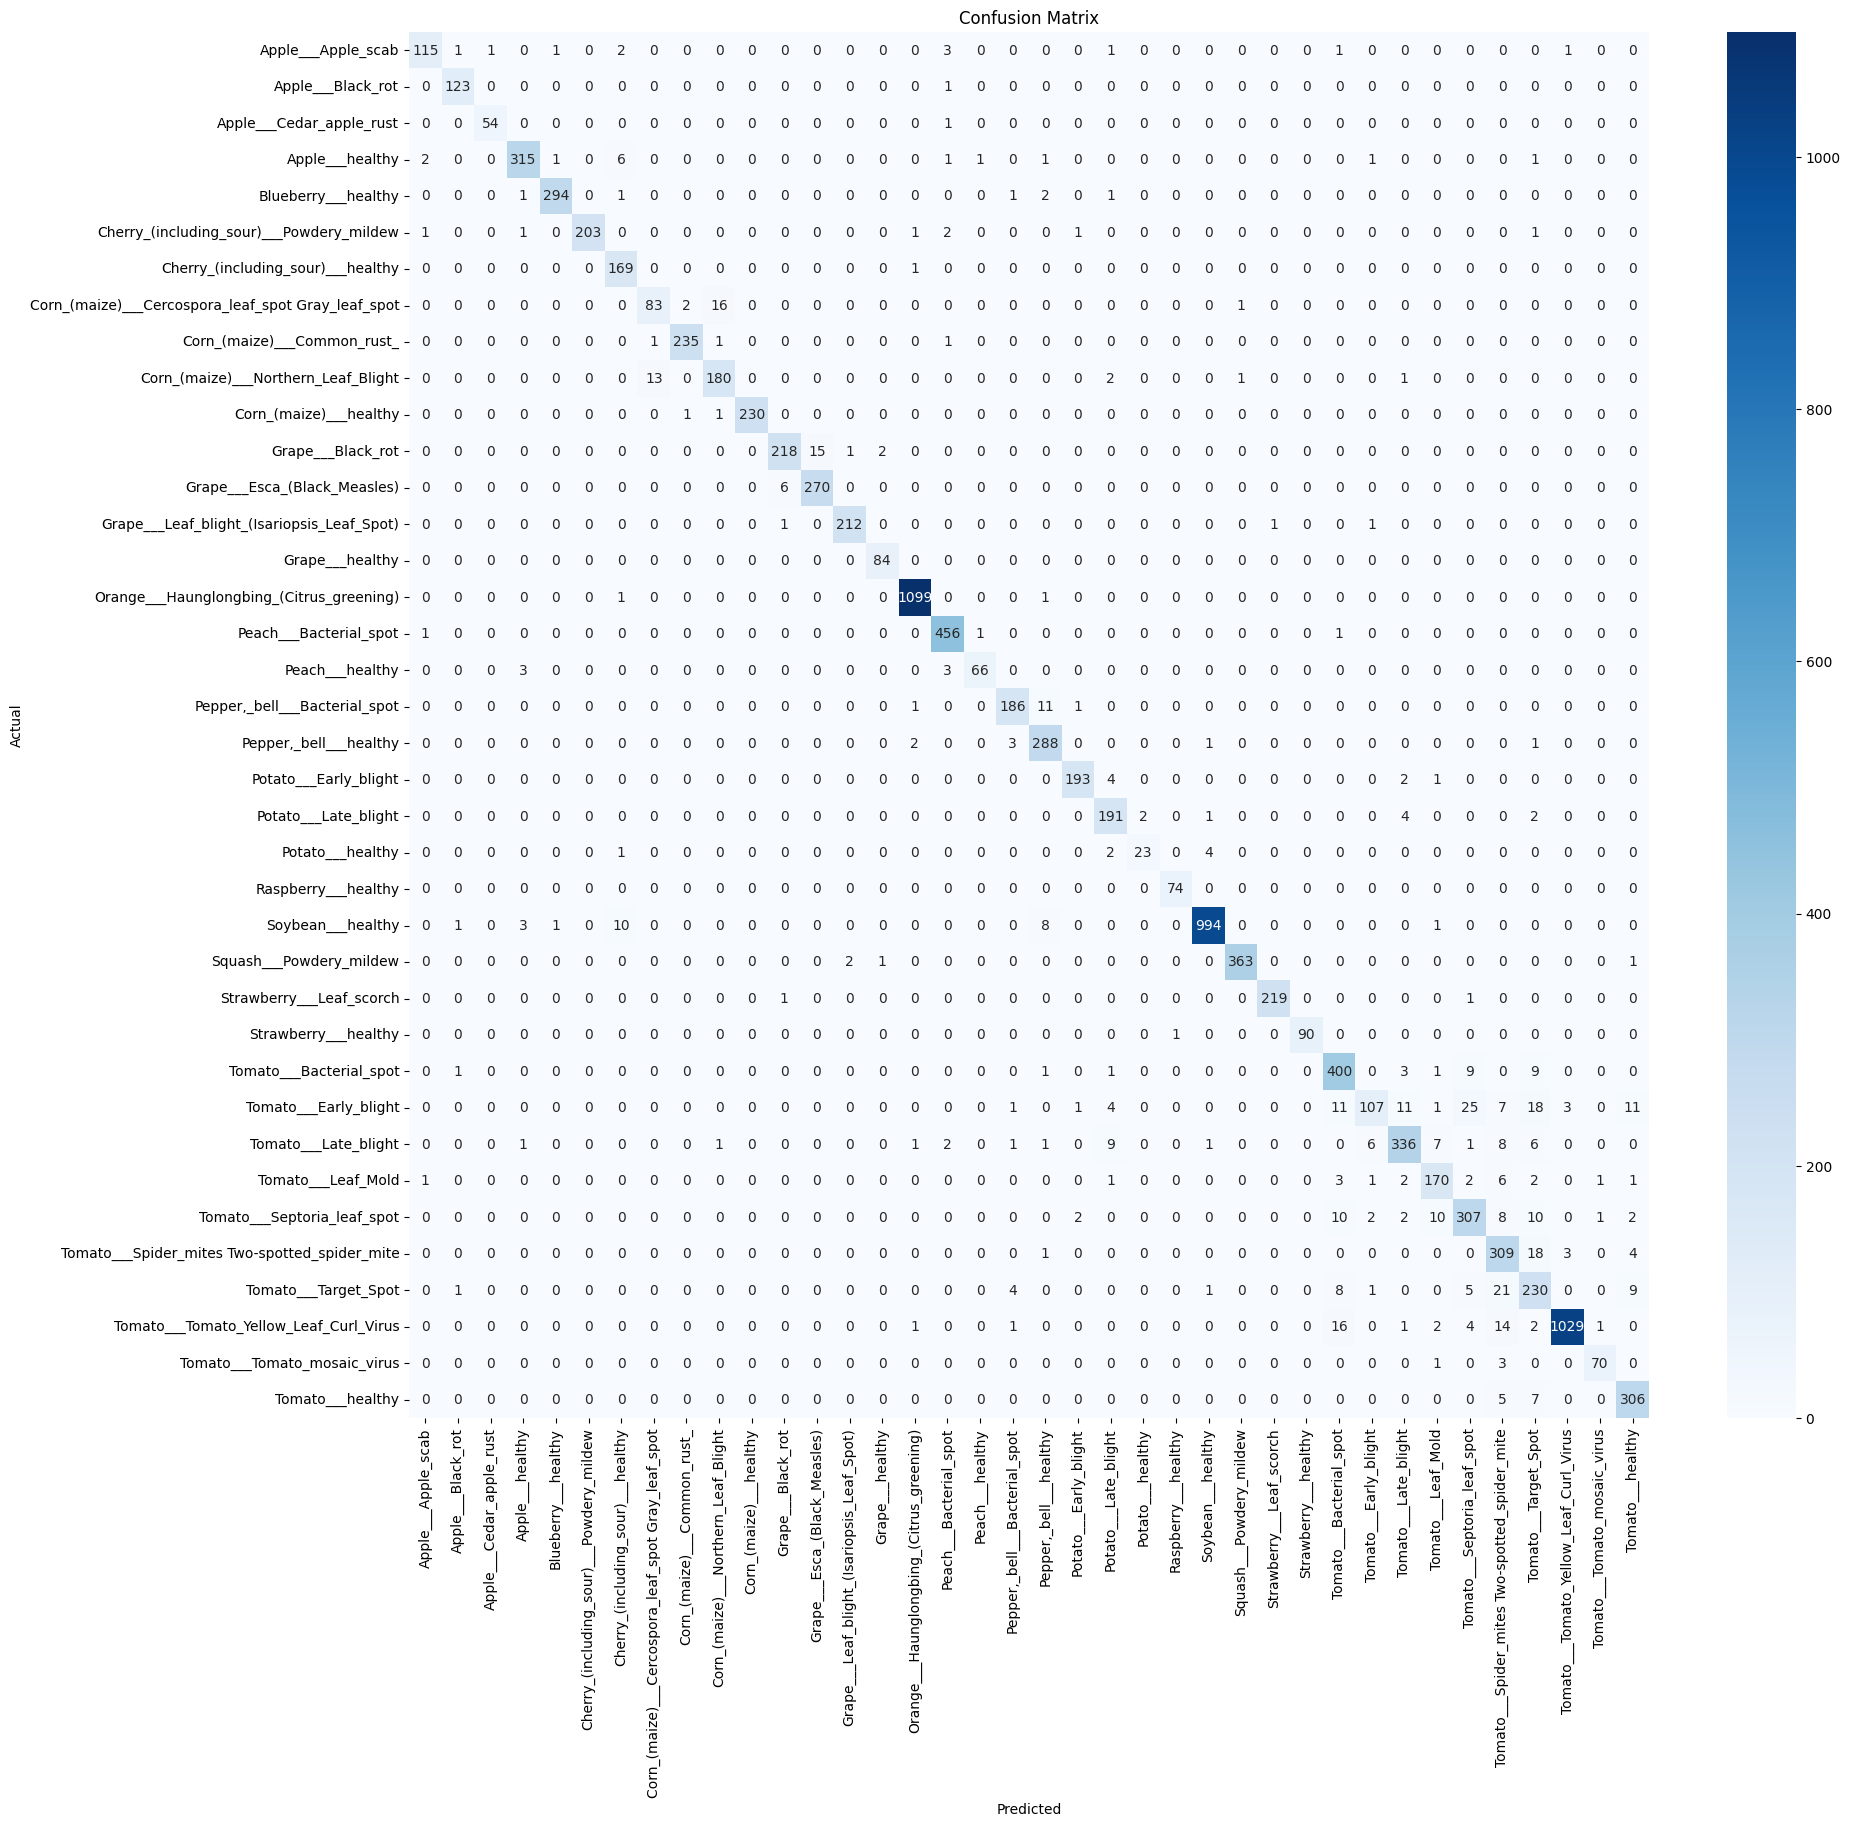

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(20,18))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

18. Create Prediction Function

In [ ]:
import numpy as np

def predict(model, img):
    img_array = np.expand_dims(img, axis=0)
    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)

    return predicted_class, confidence

19. Visualize Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


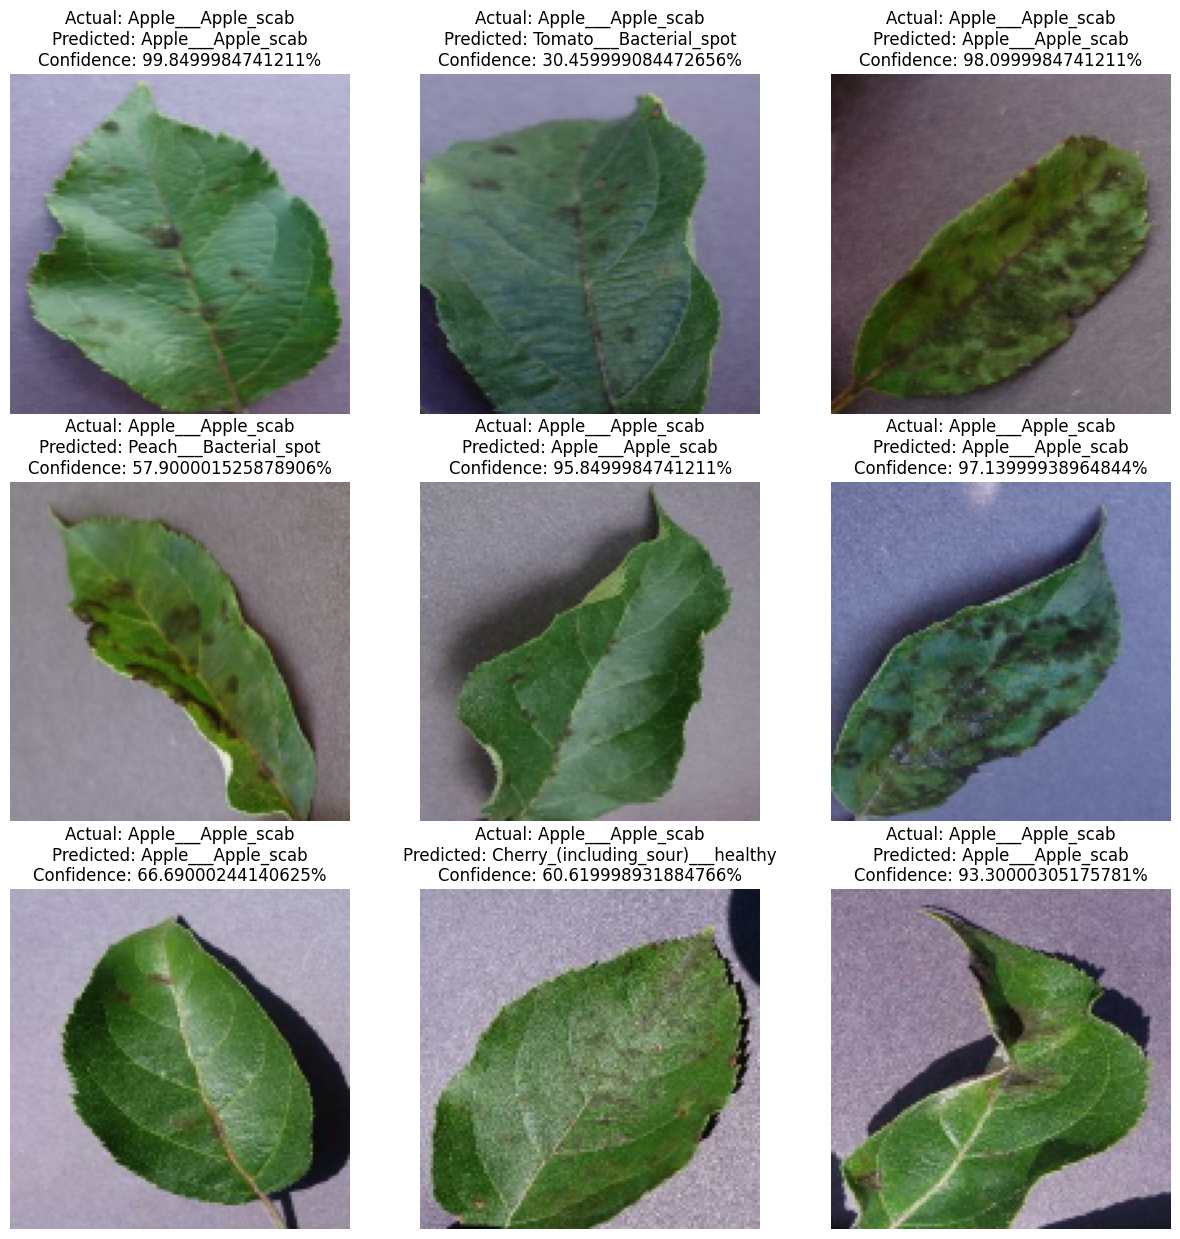

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15))

for images, labels in test_ds.take(1):
    for i in range(9):

        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")

        plt.axis("off")